# 02 Population dynamics

PCA trajectory and speed tuning curves using synthetic motor-cortex-like activity.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.stats import binned_statistic

plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(13)

In [2]:
T = 500
N = 48
time = np.linspace(0, 20, T)
latent = np.column_stack([
    np.sin(0.8 * time),
    np.cos(0.6 * time + 0.3),
    np.sin(0.25 * time + 1.0),
])
W = rng.normal(scale=0.9, size=(3, N))
rates = latent @ W + 0.3 * rng.normal(size=(T, N))
rates = (rates - rates.mean(axis=0)) / rates.std(axis=0)

traj = np.column_stack([
    np.cumsum(0.06 * latent[:, 0] + 0.01 * rng.normal(size=T)),
    np.cumsum(0.06 * latent[:, 1] + 0.01 * rng.normal(size=T)),
])
vel = np.gradient(traj, axis=0)
speed = np.linalg.norm(vel, axis=1)

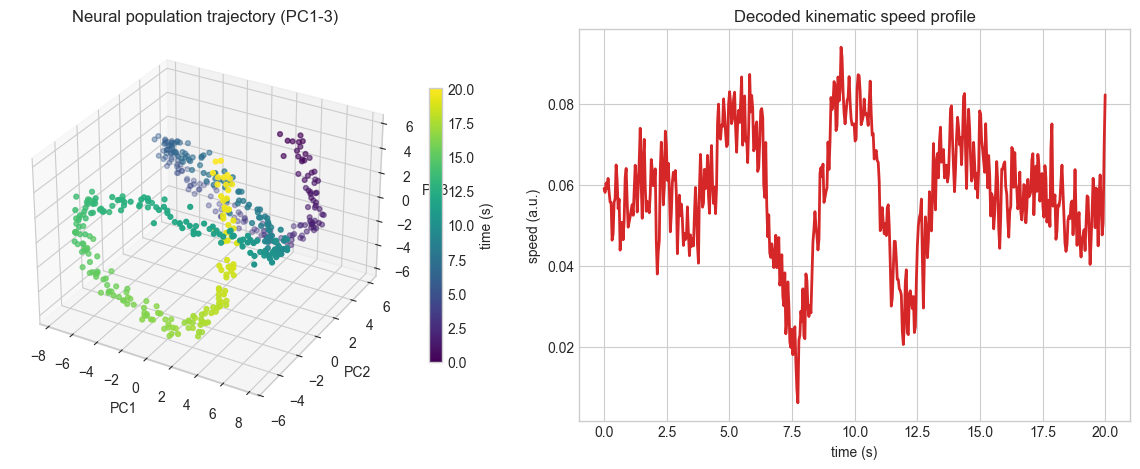

In [3]:
pca = PCA(n_components=3, random_state=0)
pcs = pca.fit_transform(rates)

fig = plt.figure(figsize=(12, 4.8))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
sc = ax1.scatter(pcs[:,0], pcs[:,1], pcs[:,2], c=time, cmap='viridis', s=12)
ax1.set_title('Neural population trajectory (PC1-3)')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_zlabel('PC3')
fig.colorbar(sc, ax=ax1, shrink=0.7, label='time (s)')

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(time, speed, color='tab:red', linewidth=2)
ax2.set_title('Decoded kinematic speed profile')
ax2.set_xlabel('time (s)')
ax2.set_ylabel('speed (a.u.)')
fig.tight_layout()

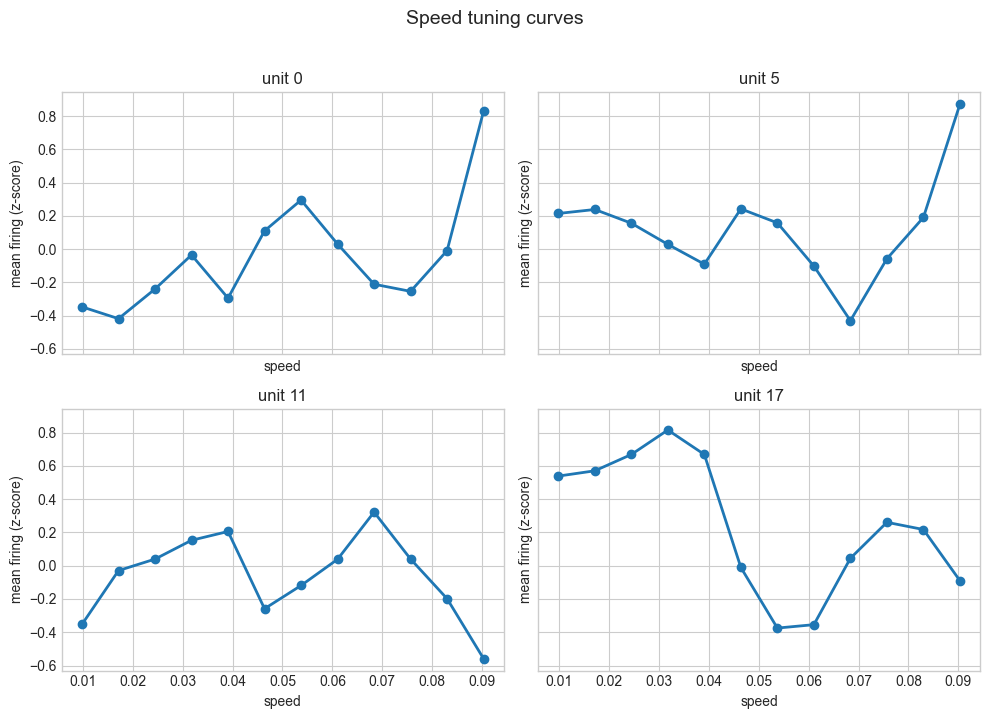

In [4]:
# Speed tuning curves for selected neurons
selected_units = [0, 5, 11, 17]
fig, ax = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
for subplot, unit in zip(ax.ravel(), selected_units):
    means, bin_edges, _ = binned_statistic(speed, rates[:, unit], statistic='mean', bins=12)
    centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    subplot.plot(centers, means, marker='o', linewidth=2)
    subplot.set_title(f'unit {unit}')
    subplot.set_xlabel('speed')
    subplot.set_ylabel('mean firing (z-score)')
fig.suptitle('Speed tuning curves', y=1.02, fontsize=14)
fig.tight_layout()